# Notebook 24c：PnP、ICP 与因子图 SLAM 基础

## 1. 定位
连接视觉几何与状态估计：PnP 从 2D-3D 对应求解相机位姿，ICP 从 3D-3D 对应求解刚体变换，因子图将它们统一为非线性最小二乘。

## 2. 学习目标
- ⭐ PnP：最小化重投影误差求解 $\mathbf{T}_{cw}$
- ⭐ ICP：point-to-point 和 point-to-plane
- ⭐ 因子图：位姿图优化 = 稀疏非线性最小二乘
- 📖 RANSAC 外点剔除

## 3. Python — PnP 简化实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import sys; sys.path.insert(0, '..')
from src.robotics_learning.transforms import so3_exp, so3_log, axis_angle_to_rot
%matplotlib inline
rng = np.random.RandomState(42)
print("✅ 导入完成")

✅ 导入完成


In [2]:
# 真值相机位姿
R_true = axis_angle_to_rot(np.array([0.2, -0.1, 0.3]), 0.5)
t_true = np.array([1.0, 0.5, 2.0])
K_pnp = np.array([[500, 0, 320], [0, 500, 240], [0, 0, 1]])

# 3D 点 + 投影
n_pts = 15
pts_3d = rng.uniform(-2, 2, (n_pts, 3)) + np.array([0, 0, 5])
pts_2d = np.array([K_pnp @ (R_true @ p + t_true) for p in pts_3d])
pts_2d = pts_2d[:, :2] / pts_2d[:, 2, None]
pts_2d += rng.normal(0, 2, pts_2d.shape)  # 噪声

# PnP: 从 2D-3D 对应求解 R, t
def reprojection_error(params, pts_3d, pts_2d, K):
    omega = params[:3]; t = params[3:]
    R = so3_exp(omega)
    errors = []
    for p3, p2 in zip(pts_3d, pts_2d):
        pc = R @ p3 + t
        uv = K @ pc; uv = uv[:2]/uv[2]
        errors.extend(uv - p2)
    return np.array(errors)

res = least_squares(reprojection_error, np.zeros(6), args=(pts_3d, pts_2d, K_pnp))
R_est = so3_exp(res.x[:3]); t_est = res.x[3:]

print(f"R_true:\n{np.round(R_true, 4)}")
print(f"R_est:\n{np.round(R_est, 4)}")
print(f"t_true: {np.round(t_true, 4)}")
print(f"t_est:  {np.round(t_est, 4)}")
print(f"Rotation error: {np.linalg.norm(so3_log(R_est.T @ R_true)):.4f} rad")
print(f"Translation error: {np.linalg.norm(t_est - t_true):.4f} m")

# 重投影可视化
for p, R, t, c, label in [(pts_3d, R_true, t_true, 'green', 'True'), (pts_3d, R_est, t_est, 'blue', 'Estimated')]:
    pass  # 略过在此

R_true:
[[ 0.9126 -0.4019 -0.0757]
 [ 0.3669  0.8863 -0.2825]
 [ 0.1806  0.23    0.9563]]
R_est:
[[ 0.9119 -0.4021 -0.0821]
 [ 0.3644  0.8854 -0.2887]
 [ 0.1888  0.2333  0.9539]]
t_true: [1.  0.5 2. ]
t_est:  [1.0275 0.5347 1.9912]
Rotation error: 0.0092 rad
Translation error: 0.0451 m


### ICP — Point-to-Point

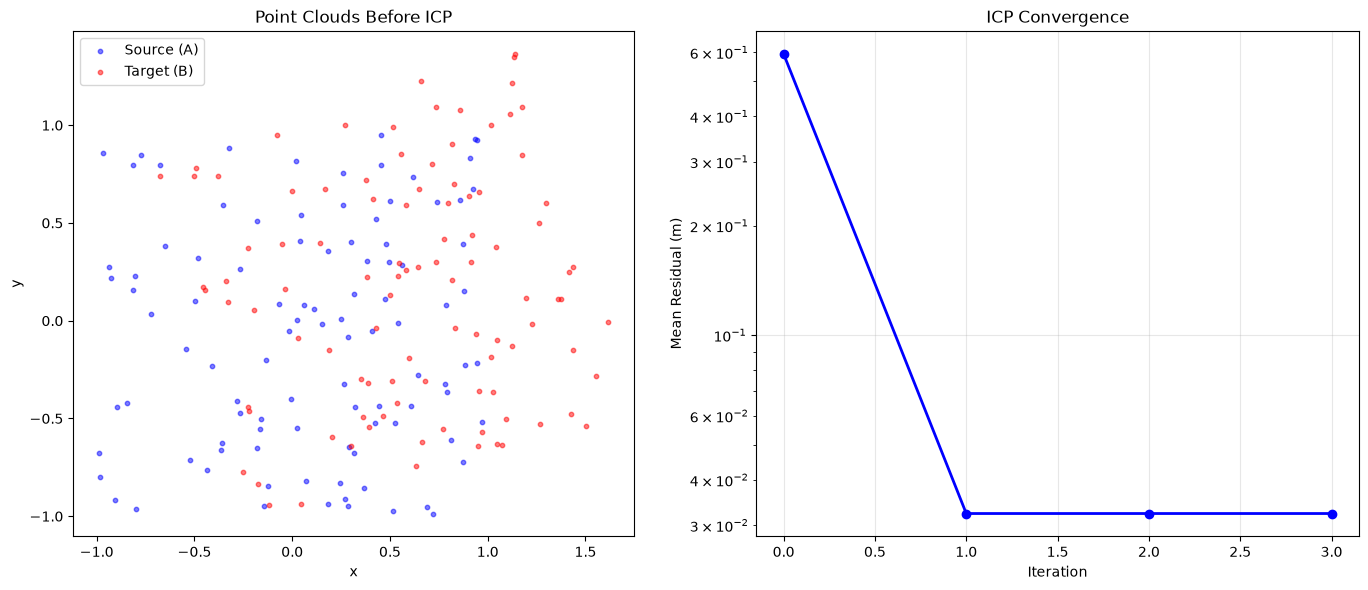

ICP: R error = 0.0038 rad, t error = 0.0021 m


In [3]:
# 生成两个点云（真值变换 + 噪声）
R_icp_true = axis_angle_to_rot(np.array([0, 0, 1]), 0.3)
t_icp_true = np.array([0.5, 0.2, 0.0])
cloud_A = rng.uniform(-1, 1, (100, 3))
cloud_B = np.array([R_icp_true @ p + t_icp_true + rng.normal(0, 0.02, 3) for p in cloud_A])

# ICP 迭代 (point-to-point, 已知对应关系)
R_icp = np.eye(3); t_icp = np.zeros(3)
err_icp_hist = []

for it in range(30):
    # 1. 用当前估计变换源点云
    A_transformed = np.array([R_icp @ p + t_icp for p in cloud_A])

    # 2. 最近邻关联 (简化：假设对应关系已知)
    residuals = cloud_B - A_transformed
    err_icp_hist.append(np.mean(np.linalg.norm(residuals, axis=1)))

    # 3. 求解增量变换 ΔR, Δt: min Σ||ΔR·a_i + Δt - b_i||²
    centroid_A = np.mean(A_transformed, axis=0)
    centroid_B = np.mean(cloud_B, axis=0)
    H = (A_transformed - centroid_A).T @ (cloud_B - centroid_B)
    U, _, Vt = np.linalg.svd(H)
    R_delta = Vt.T @ U.T
    if np.linalg.det(R_delta) < 0:
        Vt[-1] *= -1; R_delta = Vt.T @ U.T
    t_delta = centroid_B - R_delta @ centroid_A

    # 4. 组合增量
    R_icp = R_delta @ R_icp
    t_icp = R_delta @ t_icp + t_delta

    # 收敛判断
    if it > 2 and abs(err_icp_hist[-1] - err_icp_hist[-2]) < 1e-8:
        break

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(cloud_A[:,0], cloud_A[:,1], c='blue', s=10, alpha=0.5, label='Source (A)')
axes[0].scatter(cloud_B[:,0], cloud_B[:,1], c='red', s=10, alpha=0.5, label='Target (B)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].set_aspect('equal')
axes[0].set_title('Point Clouds Before ICP'); axes[0].legend()
axes[1].semilogy(err_icp_hist, 'b-o', linewidth=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Mean Residual (m)')
axes[1].set_title('ICP Convergence'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/24c_icp.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"ICP: R error = {np.linalg.norm(so3_log(R_icp.T @ R_icp_true)):.4f} rad, t error = {np.linalg.norm(t_icp - t_icp_true):.4f} m")

### 因子图 SLAM — 位姿图优化

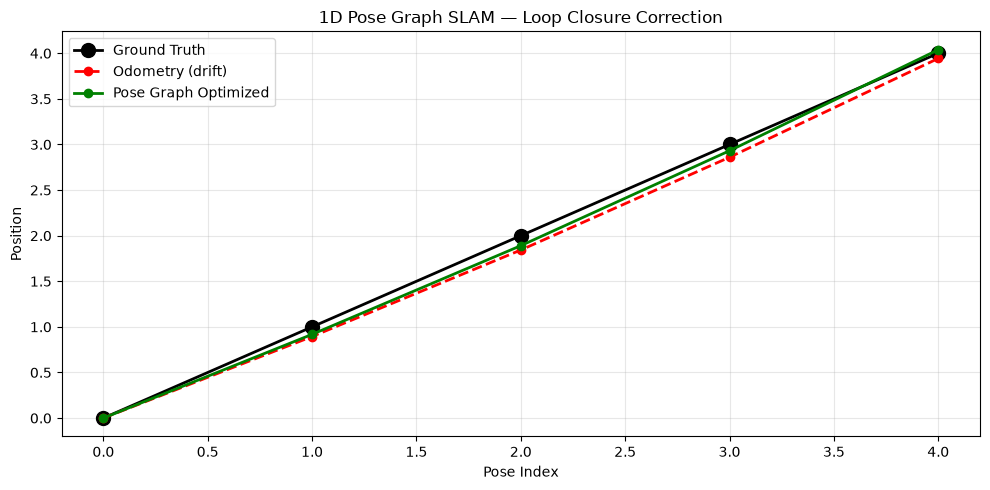

Odom 最大漂移: 0.16
优化后最大误差: 0.1096


In [4]:
# 1D 环形位姿图：5 个节点，odometry 边 + 1 个回环边
n_poses = 5
poses_true = np.arange(n_poses, dtype=float)
poses_true = np.concatenate([poses_true, [poses_true[0]]])  # 回环

# Odometry 测量（带噪声）
odom = np.diff(poses_true[:n_poses]) + rng.normal(0, 0.1, n_poses-1)
# 优化前：里程计累加（漂移）
poses_odom = np.zeros(n_poses)
poses_odom[0] = 0
for i in range(1, n_poses):
    poses_odom[i] = poses_odom[i-1] + odom[i-1]

# 回环测量
loop_closure = poses_true[-1] - poses_true[n_poses-1] + rng.normal(0, 0.05)

# 因子图优化: min Σ_w · ||x_j - x_i - z_{ij}||²
# 以 ||Ax - b||² 形式: 对每条边, A 中 x_j 的系数为 +√w, x_i 的系数为 -√w
n_edges = (n_poses - 1) + 1  # odom edges + loop closure
A_pose = np.zeros((n_edges, n_poses))
b_pose = np.zeros(n_edges)
row = 0

# Odometry edges: x_{i+1} - x_i = odom_i (weight=1)
for i in range(n_poses - 1):
    A_pose[row, i] = -1.0; A_pose[row, i+1] = 1.0
    b_pose[row] = odom[i]
    row += 1

# Loop closure: x_0 - x_{n-1} = loop_closure (higher weight)
w_lc = 4.0  # 回环权重 > 里程计
A_pose[row, n_poses-1] = -np.sqrt(w_lc)
A_pose[row, 0] = np.sqrt(w_lc)
b_pose[row] = np.sqrt(w_lc) * loop_closure

# 固定 anchor: x_0 = 0 (硬约束，通过加一行大权重)
A_anchor = np.zeros((1, n_poses)); A_anchor[0, 0] = 1000.0
b_anchor = np.zeros(1)
A_aug = np.vstack([A_pose, A_anchor])
b_aug = np.concatenate([b_pose, b_anchor])

# Solve: A^T A x = A^T b
H = A_aug.T @ A_aug; rhs = A_aug.T @ b_aug
poses_opt = np.linalg.solve(H, rhs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(poses_true[:n_poses], 'ko-', linewidth=2, markersize=10, label='Ground Truth')
ax.plot(poses_odom, 'r--o', linewidth=2, label='Odometry (drift)')
ax.plot(poses_opt, 'g-o', linewidth=2, label='Pose Graph Optimized')
ax.set_xlabel('Pose Index'); ax.set_ylabel('Position')
ax.set_title('1D Pose Graph SLAM — Loop Closure Correction'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/24c_pose_graph_slam.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Odom 最大漂移: {np.max(np.abs(poses_odom-poses_true[:n_poses])):.2f}")
print(f"优化后最大误差: {np.max(np.abs(poses_opt-poses_true[:n_poses])):.4f}")

## 4. 练习题
1. PnP 和 ICP 分别解决什么问题？输入输出各是什么？
2. 因子图优化中为什么需要 anchor 节点？
3. 回环检测对 SLAM 精度的贡献？